# 83 — LSEG-33 prompt-engineered economic value

Five target-specific Gemma prompt variants are scored on the fixed 9,317-event
Reuters company-session population. Prompt selection uses 2024 only. A prompt
may open the 2025 retrospective test only if it passes the frozen development
gate. Numeric 2026 prices and returns remain sealed.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "final_experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.lseg_materiality_returns import (  # noqa: E402
    attach_forward_open_returns,
    benjamini_hochberg_qvalues,
    circular_block_mean_test,
    load_preconfirmation_lseg_prices,
    run_sparse_strategy,
    summarize_sparse_strategy,
)
from final_experiments.lib.lseg_prompt_value import (  # noqa: E402
    EXPECTED_CANDIDATE_EVENTS,
    EXPECTED_PROMPTS,
    load_prompt_variants,
    prompt_value_paths,
    total_reported_experiment_cost,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    STATUS,
    annotate_source,
    apply_house_style,
    zero_line,
)
from sentiment_benchmark.artifact_io import (  # noqa: E402
    atomic_write_json,
    read_json,
    read_jsonl,
    sha256_file,
)

apply_house_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SPEC_PATH = ROOT / "final_experiments/frozen_specs/lseg_prompt_economic_value_v1_20260813.json"
AUTH_PATH = ROOT / "final_experiments/frozen_specs/lseg_prompt_economic_value_external_authorisation_20260813.json"
COMPARATOR_PATH = ROOT / "final_experiments/frozen_specs/lseg_prompt_economic_value_comparator_clarification_20260813.json"
TIMEOUT_PATH = ROOT / "final_experiments/frozen_specs/lseg_prompt_economic_value_operational_timeout_amendment_20260813.json"
COMPLETE_CASE_PATH = ROOT / "final_experiments/frozen_specs/lseg_prompt_economic_value_complete_case_amendment_20260813.json"
QUALITY_GATE_V2_PATH = ROOT / "final_experiments/frozen_specs/lseg_prompt_economic_value_quality_gate_v2_20260813.json"
TEST_BOUNDARY_INCIDENT_PATH = ROOT / "final_experiments/frozen_specs/lseg_prompt_economic_value_test_boundary_incident_20260813.json"
PRICE_PATH = ROOT / "Data/derived/prices/lseg_us_sector_33_2024_2026.csv"
OUTPUT = ROOT / "final_experiments/outputs/83_lseg_prompt_economic_value"
ANALYSIS_OUTPUT = OUTPUT / "analysis"
FIGURE_OUTPUT = ROOT / "dissertation/figures"
ANALYSIS_OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUT.mkdir(parents=True, exist_ok=True)

SPEC = read_json(SPEC_PATH)
AUTH = read_json(AUTH_PATH)
COMPARATOR_CLARIFICATION = read_json(COMPARATOR_PATH)
TIMEOUT_AMENDMENT = read_json(TIMEOUT_PATH)
COMPLETE_CASE_AMENDMENT = read_json(COMPLETE_CASE_PATH)
QUALITY_GATE_V2 = read_json(QUALITY_GATE_V2_PATH)
TEST_BOUNDARY_INCIDENT = read_json(TEST_BOUNDARY_INCIDENT_PATH)
assert SPEC["status"] == "frozen_before_paid_calls_and_new_prompt_scores"
assert AUTH["status"] == "authorised_before_external_prompt_scoring"
assert COMPARATOR_CLARIFICATION["status"] == "frozen_before_any_prompt_return_was_opened"
assert TIMEOUT_AMENDMENT["price_or_return_opened"] is False
assert COMPLETE_CASE_AMENDMENT["status"].endswith("before_other_prompt_results_or_any_return_access")
assert QUALITY_GATE_V2["status"] == "frozen_post_score_before_any_price_or_return_access"
assert QUALITY_GATE_V2["v1_disposition"] == "pre-return_no_go"
assert QUALITY_GATE_V2["prices_or_returns_opened"] is False
assert TEST_BOUNDARY_INCIDENT["status"] == "recorded_and_corrected_before_final_execution"
assert AUTH["maximum_spend_usd"] == 20.0

SEED = 20_260_813
COST_BPS = 10.0
BLOCK_LENGTH = 10
BOOTSTRAP_REPLICATIONS = 9_999
SELECTION_START = pd.Timestamp("2024-01-01")
TEST_START = pd.Timestamp("2025-01-01")
CONFIRMATION_START = pd.Timestamp("2026-01-01")
PROMPT_VARIANTS = {
    variant.prompt_id: variant
    for variant in load_prompt_variants(
        ROOT / "configs/strategy_research/lseg_prompt_value_variants_v1.toml"
    )
}
assert {key: value.horizon_sessions for key, value in PROMPT_VARIANTS.items()} == EXPECTED_PROMPTS

print("prompt family frozen:", list(PROMPT_VARIANTS))
print("maximum authorised / operational spend:", 20.0, "/", 19.0)
print("2026 confirmation sealed:", True)

prompt family frozen: ['reaction_h1_direct_v1', 'reaction_h5_delayed_v1', 'cashflow_revision_h5_v1', 'surprise_catalyst_h5_v1', 'redteam_consensus_h5_v1']
maximum authorised / operational spend: 20.0 / 19.0
2026 confirmation sealed: True


## Fixed design

- Return-blind population: Reuters, explicit target, first release, nontechnical,
  one event per company-session.
- Signal: `(p_positive - p_negative) × materiality weight` only when both
  `target_specific` and `new_information` are true.
- Portfolio: strongest positive and strongest negative company, 50/50 gross,
  overlapping equal tranches at the prompt's fixed h1 or h5 horizon.
- Selection: positive 2024 net economics plus quarterly stability versus the
  exact-date existing Gemma comparator.
- Test: one selected prompt in 2025 versus cash, same-date Gemma and same-date
  FinBERT, with BH over the three paired block-bootstrap tests.

In [2]:
paths = prompt_value_paths(OUTPUT)
candidate_manifest = read_json(paths.candidate_manifest)
assert candidate_manifest["status"] == "completed"
assert candidate_manifest["counts"]["candidate_events"] == EXPECTED_CANDIDATE_EVENTS
assert candidate_manifest["selection"]["prices_or_returns_loaded"] is False

candidates = pd.DataFrame(read_jsonl(paths.candidate_events))
assert len(candidates) == EXPECTED_CANDIDATE_EVENTS
assert candidates["prompt_event_id"].is_unique
assert candidates["headline_sha256"].is_unique
candidates["entry_session"] = pd.to_datetime(candidates["entry_session"], errors="raise").dt.normalize()

score_manifests: dict[str, dict[str, object]] = {}
score_support_rows: list[dict[str, object]] = []
panel = candidates.copy()
for prompt_id, variant in PROMPT_VARIANTS.items():
    manifest = read_json(paths.manifest(prompt_id))
    assert manifest["status"] in {"completed", "incomplete"}
    assert manifest["counts"]["successful_unique"] >= (
        QUALITY_GATE_V2["v2_minimum_gate"]["each_prompt_strict_success_share"]
        * EXPECTED_CANDIDATE_EVENTS
    )
    assert manifest["identity"]["prompt_hash"] == variant.prompt_hash
    assert manifest["identity"]["horizon_sessions"] == variant.horizon_sessions
    score_manifests[prompt_id] = manifest
    scores = pd.DataFrame(read_jsonl(paths.scores(prompt_id)))
    assert len(scores) == manifest["counts"]["successful_unique"]
    assert scores["prompt_event_id"].is_unique
    assert scores["status"].eq("success").all()
    assert scores["prompt_hash"].eq(variant.prompt_hash).all()
    score_slice = scores[
        [
            "prompt_event_id",
            "headline_sha256",
            "trade_signal",
            "signed_probability",
            "target_specific",
            "new_information",
            "materiality",
        ]
    ].rename(
        columns={
            "trade_signal": prompt_id,
            "signed_probability": f"{prompt_id}__signed_probability",
            "target_specific": f"{prompt_id}__target_specific",
            "new_information": f"{prompt_id}__new_information",
            "materiality": f"{prompt_id}__materiality",
        }
    )
    panel = panel.merge(
        score_slice,
        on=["prompt_event_id", "headline_sha256"],
        how="inner",
        validate="one_to_one",
    )
    score_support_rows.append(
        {
            "prompt_id": prompt_id,
            "horizon_sessions": variant.horizon_sessions,
            "events": len(scores),
            "missing_strict_success": EXPECTED_CANDIDATE_EVENTS - len(scores),
            "target_specific_share": float(scores["target_specific"].mean()),
            "new_information_share": float(scores["new_information"].mean()),
            "nonzero_signal_share": float(scores["trade_signal"].ne(0).mean()),
            "reported_cost_usd": float(manifest["usage"]["reported_cost_usd"]),
            "invalid_successes": 0,
        }
    )

score_support = pd.DataFrame(score_support_rows)
experiment_cost = total_reported_experiment_cost(paths)
assert experiment_cost <= float(SPEC["authorisation_and_spend"]["operational_spend_ceiling_usd"])
complete_case_retained_share = len(panel) / EXPECTED_CANDIDATE_EVENTS
v1_complete_case_gate_pass = bool(
    complete_case_retained_share
    >= COMPLETE_CASE_AMENDMENT["minimum_gate"]["retained_share_of_9317"]
)
assert v1_complete_case_gate_pass is False
assert complete_case_retained_share >= QUALITY_GATE_V2["v2_minimum_gate"]["strict_intersection_share"]
assert panel["symbol"].nunique() == QUALITY_GATE_V2["v2_minimum_gate"]["companies"]

development_events = panel.loc[panel["entry_session"].lt(CONFIRMATION_START)].copy()
# The shared sparse-portfolio helper uses ``audit_id`` solely as a stable
# deterministic tie-break key.  This population's equivalent immutable key is
# ``prompt_event_id``; retain both names rather than changing the helper used by
# the earlier materiality notebooks.
development_events["audit_id"] = development_events["prompt_event_id"]
assert development_events["symbol"].nunique() == 33
assert set(development_events["entry_session"].dt.year.unique()) == {2024, 2025}

display(score_support)
display(
    development_events.groupby(development_events["entry_session"].dt.year).agg(
        events=("prompt_event_id", "size"),
        sessions=("entry_session", "nunique"),
        companies=("symbol", "nunique"),
    )
)
print("authoritative prompt-experiment cost, USD:", f"{experiment_cost:.6f}")
print("strict five-prompt complete-case retained share:", f"{complete_case_retained_share:.4%}")
print("original v1 99% gate passed:", v1_complete_case_gate_pass)
print("v2 post-score/pre-return 98% feasibility gate passed:", True)

,prompt_id,horizon_sessions,events,missing_strict_success,target_specific_share,new_information_share,nonzero_signal_share,reported_cost_usd,invalid_successes
0,reaction_h1_direct_v1,1,9306,11,0.752525,0.704169,0.296368,0.594983,0
1,reaction_h5_delayed_v1,5,9288,29,0.850991,0.763135,0.369509,0.586070,0
2,cashflow_revision_h5_v1,5,9273,44,0.795104,0.771703,0.405370,0.594840,0
3,surprise_catalyst_h5_v1,5,9293,24,0.688368,0.633810,0.275369,0.605198,0
4,redteam_consensus_h5_v1,5,9256,61,0.818280,0.759291,0.409788,0.589825,0


,events,sessions,companies
entry_session,,,
2024,3208,252,33
2025,3843,250,33


authoritative prompt-experiment cost, USD: 2.970917
strict five-prompt complete-case retained share: 98.6906%
original v1 99% gate passed: False
v2 post-score/pre-return 98% feasibility gate passed: True


## Attach only pre-2026 LSEG opens

The loader inspects dates before parsing numeric prices. Rows from 2026 onward
are skipped, so the confirmation period cannot enter any return or portfolio.

In [3]:
prices, price_audit = load_preconfirmation_lseg_prices(
    PRICE_PATH,
    expected_sha256=SPEC["immutable_inputs"]["price_export"]["sha256"],
)
selection_events = development_events.loc[
    development_events["entry_session"].lt(TEST_START)
].copy()
return_panel, wide_prices = attach_forward_open_returns(
    selection_events,
    prices,
    horizons=(1, 5),
)
assert price_audit["numeric_confirmation_prices_parsed"] == 0
assert price_audit["confirmation_returns_materialised"] == 0
assert wide_prices.index.max() < CONFIRMATION_START
assert return_panel["entry_session"].max() < TEST_START

support = pd.DataFrame(
    [
        {
            "candidate_events": len(panel),
            "return_blind_parent_events": EXPECTED_CANDIDATE_EVENTS,
            "strict_complete_case_retained_share": complete_case_retained_share,
            "v1_99pct_complete_case_gate_pass": v1_complete_case_gate_pass,
            "v2_98pct_complete_case_gate_pass": True,
            "selection_events": len(return_panel),
            "selection_sessions": return_panel["entry_session"].nunique(),
            "companies": return_panel["symbol"].nunique(),
            "h1_return_rows": return_panel["ret_open_h1"].notna().sum(),
            "h5_return_rows": return_panel["ret_open_h5"].notna().sum(),
            "numeric_2026_prices_parsed": 0,
            "confirmation_returns_materialised": 0,
            "test_2025_event_returns_materialised_in_final_execution": 0,
            "reported_api_cost_usd": experiment_cost,
        }
    ]
)
display(support.T)

,0
candidate_events,9195
return_blind_parent_events,9317
strict_complete_case_retained_share,0.986906
v1_99pct_complete_case_gate_pass,False
v2_98pct_complete_case_gate_pass,True
selection_events,3208
selection_sessions,252
companies,33
h1_return_rows,3208
h5_return_rows,3208


In [4]:
def run_window(
    events: pd.DataFrame,
    *,
    signal_col: str,
    horizon: int,
    start: pd.Timestamp,
    end: pd.Timestamp,
    formation_dates: set[pd.Timestamp] | None = None,
    force_cross_sectional_extremes: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, object]]:
    """Run one strategy window without allowing outcomes to cross its end."""

    end_col = f"return_end_h{horizon}"
    use = events.loc[
        events["entry_session"].ge(start)
        & events["entry_session"].lt(end)
        & events[end_col].notna()
        & events[end_col].lt(end)
    ].copy()
    if formation_dates is not None:
        use = use.loc[use["entry_session"].isin(formation_dates)].copy()
    effective_signal = signal_col
    if force_cross_sectional_extremes:
        effective_signal = f"{signal_col}__cross_sectional_order"
        use = use.sort_values(
            ["entry_session", signal_col, "prompt_event_id"], kind="mergesort"
        )
        within_date_order = use.groupby("entry_session", sort=False).cumcount().astype(float)
        within_date_size = use.groupby("entry_session", sort=False)["prompt_event_id"].transform("size")
        use[effective_signal] = within_date_order - (within_date_size.astype(float) - 1.0) / 2.0
    daily, formations = run_sparse_strategy(
        use,
        wide_prices,
        signal_col=effective_signal,
        horizon=horizon,
        cost_bps_per_side=COST_BPS,
    )
    daily = daily.loc[
        daily["session_date"].ge(start)
        & daily["return_end_date"].lt(end)
    ].reset_index(drop=True)
    summary = {
        "formation_sessions": len(formations),
        **summarize_sparse_strategy(daily, cost_bps_per_side=COST_BPS),
    }
    return daily, formations, summary


def prompt_and_matched_baselines(
    events: pd.DataFrame,
    *,
    prompt_id: str,
    horizon: int,
    start: pd.Timestamp,
    end: pd.Timestamp,
) -> dict[str, object]:
    prompt_daily, prompt_formations, prompt_summary = run_window(
        events,
        signal_col=prompt_id,
        horizon=horizon,
        start=start,
        end=end,
    )
    dates = set(pd.to_datetime(prompt_formations["entry_session"]).dt.normalize())
    arms: dict[str, object] = {
        "prompt_daily": prompt_daily,
        "prompt_formations": prompt_formations,
        "prompt_summary": prompt_summary,
    }
    for baseline in ("score_gemma", "score_finbert"):
        daily, formations, summary = run_window(
            events,
            signal_col=baseline,
            horizon=horizon,
            start=start,
            end=end,
            formation_dates=dates,
            force_cross_sectional_extremes=True,
        )
        if set(pd.to_datetime(formations["entry_session"]).dt.normalize()) != dates:
            raise AssertionError(f"{baseline} comparator did not match prompt formation dates")
        arms[f"{baseline}_daily"] = daily
        arms[f"{baseline}_formations"] = formations
        arms[f"{baseline}_summary"] = summary
    return arms


def paired_mean_difference(
    left: pd.DataFrame,
    right: pd.DataFrame,
) -> pd.Series:
    joined = left[["session_date", "net_return"]].merge(
        right[["session_date", "net_return"]],
        on="session_date",
        how="inner",
        validate="one_to_one",
        suffixes=("_left", "_right"),
    )
    return joined["net_return_left"] - joined["net_return_right"]


quarter_bounds = tuple(
    (pd.Timestamp(start), pd.Timestamp(end))
    for start, end in (
        ("2024-01-01", "2024-04-01"),
        ("2024-04-01", "2024-07-01"),
        ("2024-07-01", "2024-10-01"),
        ("2024-10-01", "2025-01-01"),
    )
)

## 2024 prompt selection

A prompt must be net-positive after 10 bps/side, have break-even of at least
10 bps/side, form on at least 80 sessions, be positive in at least three
quarters, and beat the same-date existing Gemma portfolio in at least three
quarters. The deterministic score is the worst quarterly net-mean difference
versus same-date Gemma.

In [5]:
selection_rows: list[dict[str, object]] = []
quarter_rows: list[dict[str, object]] = []
selection_paths: dict[str, dict[str, object]] = {}
for prompt_id, variant in PROMPT_VARIANTS.items():
    full = prompt_and_matched_baselines(
        return_panel,
        prompt_id=prompt_id,
        horizon=variant.horizon_sessions,
        start=SELECTION_START,
        end=TEST_START,
    )
    selection_paths[prompt_id] = full
    prompt_summary = full["prompt_summary"]
    quarterly_prompt_means: list[float] = []
    quarterly_deltas: list[float] = []
    for quarter_number, (start, end) in enumerate(quarter_bounds, start=1):
        quarter = prompt_and_matched_baselines(
            return_panel,
            prompt_id=prompt_id,
            horizon=variant.horizon_sessions,
            start=start,
            end=end,
        )
        prompt_mean = float(quarter["prompt_summary"]["mean_net_bps_session"])
        gemma_mean = float(quarter["score_gemma_summary"]["mean_net_bps_session"])
        delta = prompt_mean - gemma_mean
        quarterly_prompt_means.append(prompt_mean)
        quarterly_deltas.append(delta)
        quarter_rows.append(
            {
                "prompt_id": prompt_id,
                "horizon": variant.horizon_sessions,
                "quarter": quarter_number,
                "start": start.date().isoformat(),
                "end_exclusive": end.date().isoformat(),
                "formation_sessions": int(quarter["prompt_summary"]["formation_sessions"]),
                "prompt_net_bps_session": prompt_mean,
                "same_date_gemma_net_bps_session": gemma_mean,
                "prompt_minus_gemma_bps_session": delta,
            }
        )
    positive_quarters = int(np.sum(np.asarray(quarterly_prompt_means) > 0))
    beat_gemma_quarters = int(np.sum(np.asarray(quarterly_deltas) > 0))
    eligible = bool(
        int(prompt_summary["formation_sessions"])
        >= int(SPEC["selection"]["minimum_formation_sessions"])
        and float(prompt_summary["mean_net_bps_session"]) > 0
        and float(prompt_summary["net_sharpe"]) > 0
        and float(prompt_summary["breakeven_bps_per_side"]) >= COST_BPS
        and positive_quarters >= 3
        and beat_gemma_quarters >= 3
    )
    selection_rows.append(
        {
            "prompt_id": prompt_id,
            "horizon": variant.horizon_sessions,
            **prompt_summary,
            "same_date_gemma_mean_net_bps_session": float(
                full["score_gemma_summary"]["mean_net_bps_session"]
            ),
            "same_date_gemma_total_return_net": float(
                full["score_gemma_summary"]["total_return_net"]
            ),
            "same_date_finbert_mean_net_bps_session": float(
                full["score_finbert_summary"]["mean_net_bps_session"]
            ),
            "same_date_finbert_total_return_net": float(
                full["score_finbert_summary"]["total_return_net"]
            ),
            "prompt_minus_gemma_net_bps_session": (
                float(prompt_summary["mean_net_bps_session"])
                - float(full["score_gemma_summary"]["mean_net_bps_session"])
            ),
            "prompt_minus_finbert_net_bps_session": (
                float(prompt_summary["mean_net_bps_session"])
                - float(full["score_finbert_summary"]["mean_net_bps_session"])
            ),
            "positive_quarters": positive_quarters,
            "beat_same_date_gemma_quarters": beat_gemma_quarters,
            "minimum_quarterly_delta_vs_gemma_bps": min(quarterly_deltas),
            "mean_quarterly_delta_vs_gemma_bps": float(np.mean(quarterly_deltas)),
            "eligible": eligible,
        }
    )

selection = pd.DataFrame(selection_rows)
quarters = pd.DataFrame(quarter_rows)
eligible = selection.loc[selection["eligible"]].sort_values(
    [
        "minimum_quarterly_delta_vs_gemma_bps",
        "mean_quarterly_delta_vs_gemma_bps",
        "net_sharpe",
        "annualized_turnover",
        "prompt_id",
    ],
    ascending=[False, False, False, True, True],
    kind="mergesort",
)
selected_prompt = str(eligible.iloc[0]["prompt_id"]) if not eligible.empty else None

display(
    selection[
        [
            "prompt_id",
            "horizon",
            "formation_sessions",
            "mean_net_bps_session",
            "net_sharpe",
            "total_return_net",
            "breakeven_bps_per_side",
            "same_date_gemma_mean_net_bps_session",
            "same_date_finbert_mean_net_bps_session",
            "positive_quarters",
            "beat_same_date_gemma_quarters",
            "minimum_quarterly_delta_vs_gemma_bps",
            "eligible",
        ]
    ]
)
print("selected prompt:", selected_prompt or "NONE — no 2025 prompt portfolio computed")

,prompt_id,horizon,formation_sessions,mean_net_bps_session,net_sharpe,total_return_net,breakeven_bps_per_side,same_date_gemma_mean_net_bps_session,same_date_finbert_mean_net_bps_session,positive_quarters,beat_same_date_gemma_quarters,minimum_quarterly_delta_vs_gemma_bps,eligible
0,reaction_h1_direct_v1,1,173,-16.455243,-2.078905,-0.351382,-2.886800,-20.719185,-7.878857,1,1,-11.023190,False
1,reaction_h5_delayed_v1,5,196,-4.012411,-1.097902,-0.099629,-3.271149,-5.871699,-8.208933,1,3,-7.994037,False
2,cashflow_revision_h5_v1,5,220,-5.260480,-1.343589,-0.127947,-5.466106,-4.489670,-7.366340,2,2,-11.862044,False
3,surprise_catalyst_h5_v1,5,182,-4.492289,-1.270846,-0.110172,-5.897490,-5.348923,-6.450792,1,2,-7.247909,False
4,redteam_consensus_h5_v1,5,221,-9.543346,-2.408027,-0.216997,-18.080956,-3.670325,-6.121022,1,1,-19.172144,False


selected prompt: NONE — no 2025 prompt portfolio computed


findfont: Failed to find font weight medium, now using 400.


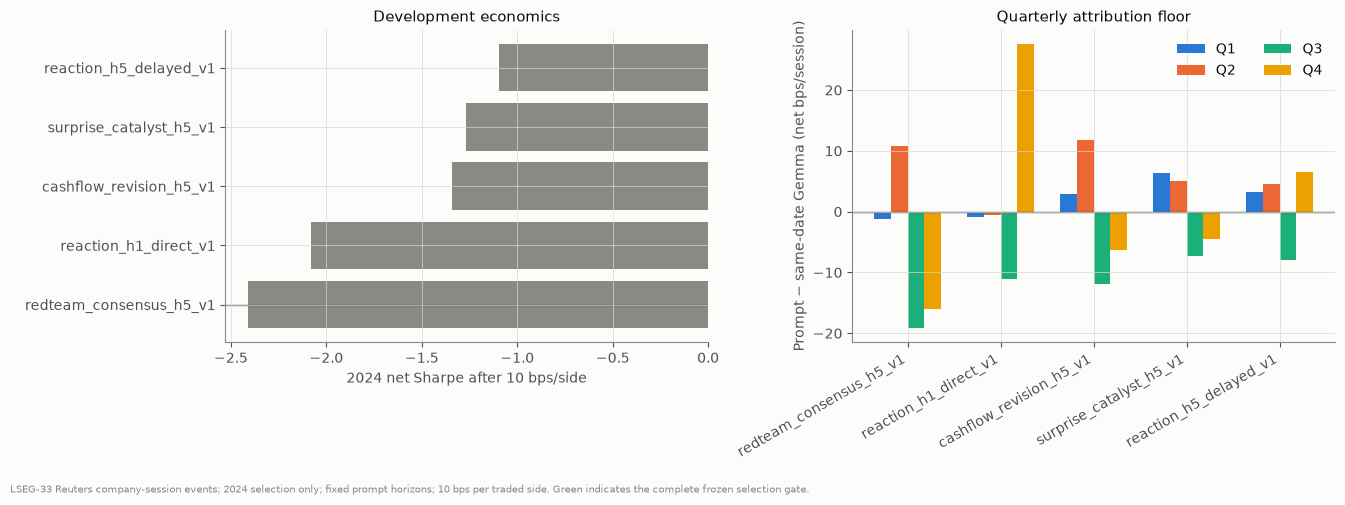

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))
ordered = selection.sort_values("net_sharpe", ascending=True)
axes[0].barh(
    ordered["prompt_id"],
    ordered["net_sharpe"],
    color=[STATUS["good"] if value else INK["muted"] for value in ordered["eligible"]],
)
zero_line(axes[0])
axes[0].set_xlabel("2024 net Sharpe after 10 bps/side")
axes[0].set_title("Development economics")

quarter_pivot = quarters.pivot(
    index="prompt_id", columns="quarter", values="prompt_minus_gemma_bps_session"
).loc[ordered["prompt_id"]]
x = np.arange(len(quarter_pivot))
width = 0.18
for offset, quarter in enumerate(quarter_pivot.columns):
    axes[1].bar(
        x + (offset - 1.5) * width,
        quarter_pivot[quarter],
        width,
        label=f"Q{quarter}",
        color=CATEGORICAL[offset],
    )
zero_line(axes[1])
axes[1].set_xticks(x, quarter_pivot.index, rotation=30, ha="right")
axes[1].set_ylabel("Prompt − same-date Gemma (net bps/session)")
axes[1].set_title("Quarterly attribution floor")
axes[1].legend(frameon=False, ncol=2)
fig.tight_layout()
annotate_source(
    fig,
    "LSEG-33 Reuters company-session events; 2024 selection only; fixed prompt "
    "horizons; 10 bps per traded side. Green indicates the complete frozen selection gate.",
)
fig.savefig(ANALYSIS_OUTPUT / "prompt_selection_2024.png", dpi=180, bbox_inches="tight")
fig.savefig(FIGURE_OUTPUT / "fig_lseg33_prompt_selection.png", dpi=180, bbox_inches="tight")
plt.show()

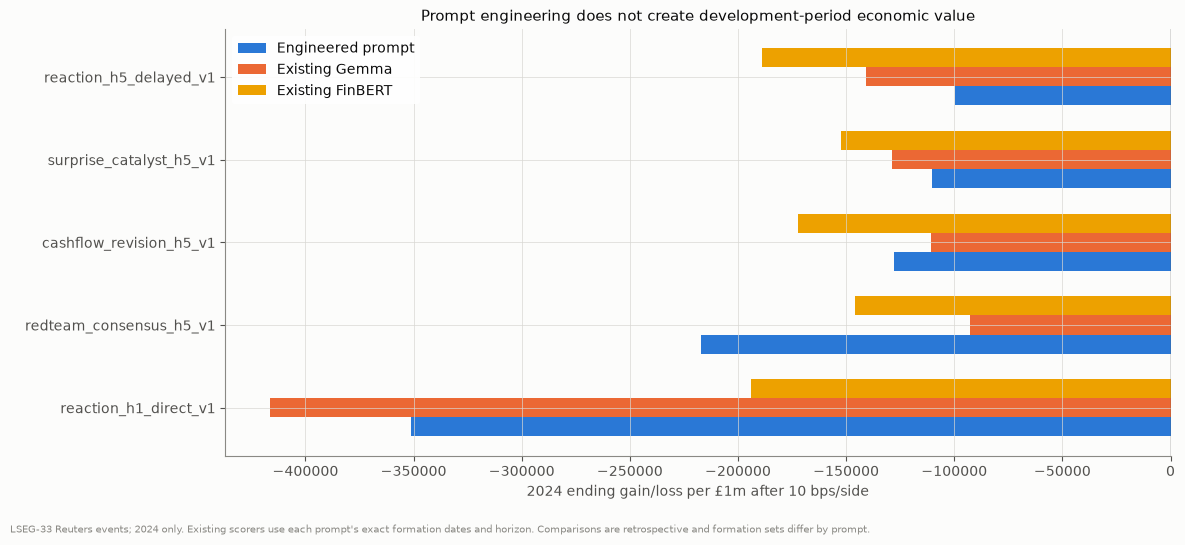

In [7]:
economic = selection.sort_values("total_return_net", ascending=True).reset_index(drop=True)
y = np.arange(len(economic))
height = 0.23
fig, ax = plt.subplots(figsize=(11.8, 5.2))
for offset, column, label, colour in (
    (-1, "total_return_net", "Engineered prompt", CATEGORICAL[0]),
    (0, "same_date_gemma_total_return_net", "Existing Gemma", CATEGORICAL[1]),
    (1, "same_date_finbert_total_return_net", "Existing FinBERT", CATEGORICAL[3]),
):
    ax.barh(
        y + offset * height,
        economic[column] * 1_000_000.0,
        height,
        label=label,
        color=colour,
    )
ax.axvline(0.0, color=INK["reference"], lw=1.0)
ax.set_yticks(y, economic["prompt_id"])
ax.set_xlabel("2024 ending gain/loss per £1m after 10 bps/side")
ax.set_title("Prompt engineering does not create development-period economic value")
ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.9,
    ncol=1,
    loc="upper left",
)
fig.tight_layout()
annotate_source(
    fig,
    "LSEG-33 Reuters events; 2024 only. Existing scorers use each prompt's exact "
    "formation dates and horizon. Comparisons are retrospective and formation sets differ by prompt.",
)
fig.savefig(ANALYSIS_OUTPUT / "prompt_economic_comparison_2024.png", dpi=180, bbox_inches="tight")
fig.savefig(
    FIGURE_OUTPUT / "fig_lseg33_prompt_economic_comparison.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## One-shot 2025 test

This cell opens 2025 only if a prompt passed every 2024 gate. It makes no
fallback selection and does not alter prompt wording, weights, costs, horizon,
or portfolio mechanics.

In [8]:
evaluation_summary = pd.DataFrame()
primary_family = pd.DataFrame()
half_stability = pd.DataFrame()
leave_one_company_out = pd.DataFrame()
concentration = pd.DataFrame()
evaluation_paths: dict[str, object] | None = None
economic_gate_pass = False

if selected_prompt is not None:
    selected_variant = PROMPT_VARIANTS[selected_prompt]
    evaluation_events = development_events.loc[
        development_events["entry_session"].ge(TEST_START)
        & development_events["entry_session"].lt(CONFIRMATION_START)
    ].copy()
    evaluation_return_panel, _ = attach_forward_open_returns(
        evaluation_events,
        prices,
        horizons=(1, 5),
    )
    evaluation_paths = prompt_and_matched_baselines(
        evaluation_return_panel,
        prompt_id=selected_prompt,
        horizon=selected_variant.horizon_sessions,
        start=TEST_START,
        end=CONFIRMATION_START,
    )
    arm_rows = []
    for arm, label in (
        ("prompt", "Selected prompt"),
        ("score_gemma", "Same-date existing Gemma"),
        ("score_finbert", "Same-date FinBERT"),
    ):
        summary = evaluation_paths[f"{arm}_summary" if arm != "prompt" else "prompt_summary"]
        arm_rows.append({"arm": arm, "label": label, **summary})
    evaluation_summary = pd.DataFrame(arm_rows)

    selected_daily = evaluation_paths["prompt_daily"]
    test_rows = []
    cash = circular_block_mean_test(
        selected_daily["net_return"],
        block_length=BLOCK_LENGTH,
        replications=BOOTSTRAP_REPLICATIONS,
        seed=SEED + 1,
        alternative="greater",
    )
    test_rows.append(
        {
            "test": "selected_prompt_vs_cash",
            "effect_bps_session": cash["mean"] * 10_000.0,
            "ci_low_bps": cash["ci_low"] * 10_000.0,
            "ci_high_bps": cash["ci_high"] * 10_000.0,
            "p_one_sided": cash["p"],
        }
    )
    for offset, baseline in enumerate(("score_gemma", "score_finbert"), start=2):
        difference = paired_mean_difference(
            selected_daily,
            evaluation_paths[f"{baseline}_daily"],
        )
        test = circular_block_mean_test(
            difference,
            block_length=BLOCK_LENGTH,
            replications=BOOTSTRAP_REPLICATIONS,
            seed=SEED + offset,
            alternative="greater",
        )
        test_rows.append(
            {
                "test": f"selected_prompt_vs_same_date_{baseline}",
                "effect_bps_session": test["mean"] * 10_000.0,
                "ci_low_bps": test["ci_low"] * 10_000.0,
                "ci_high_bps": test["ci_high"] * 10_000.0,
                "p_one_sided": test["p"],
            }
        )
    primary_family = pd.DataFrame(test_rows)
    primary_family["bh_q"] = benjamini_hochberg_qvalues(primary_family["p_one_sided"])
    primary_family["reject_q05"] = (
        primary_family["effect_bps_session"].gt(0)
        & primary_family["bh_q"].lt(0.05)
    )

    half_rows = []
    for half, start, end in (
        (1, TEST_START, pd.Timestamp("2025-07-01")),
        (2, pd.Timestamp("2025-07-01"), CONFIRMATION_START),
    ):
        half_result = prompt_and_matched_baselines(
            return_panel,
            prompt_id=selected_prompt,
            horizon=selected_variant.horizon_sessions,
            start=start,
            end=end,
        )
        half_rows.append(
            {
                "half": half,
                "start": start.date().isoformat(),
                "end_exclusive": end.date().isoformat(),
                **half_result["prompt_summary"],
                "prompt_minus_gemma_bps_session": (
                    float(half_result["prompt_summary"]["mean_net_bps_session"])
                    - float(half_result["score_gemma_summary"]["mean_net_bps_session"])
                ),
            }
        )
    half_stability = pd.DataFrame(half_rows)

    loo_rows = []
    for removed_symbol in sorted(evaluation_return_panel["symbol"].unique()):
        replay = prompt_and_matched_baselines(
            evaluation_return_panel.loc[
                ~evaluation_return_panel["symbol"].eq(removed_symbol)
            ],
            prompt_id=selected_prompt,
            horizon=selected_variant.horizon_sessions,
            start=TEST_START,
            end=CONFIRMATION_START,
        )
        loo_rows.append(
            {
                "removed_symbol": removed_symbol,
                **replay["prompt_summary"],
                "prompt_minus_gemma_bps_session": (
                    float(replay["prompt_summary"]["mean_net_bps_session"])
                    - float(replay["score_gemma_summary"]["mean_net_bps_session"])
                ),
            }
        )
    leave_one_company_out = pd.DataFrame(loo_rows)

    formations = evaluation_paths["prompt_formations"]
    counts = pd.concat(
        [
            formations["long_symbol"].value_counts().rename("long_selections"),
            formations["short_symbol"].value_counts().rename("short_selections"),
        ],
        axis=1,
    ).fillna(0).astype(int)
    concentration = counts.rename_axis("symbol").reset_index()
    concentration["total_selections"] = (
        concentration["long_selections"] + concentration["short_selections"]
    )

    selected_summary = evaluation_summary.set_index("arm").loc["prompt"]
    economic_gate_pass = bool(
        primary_family["reject_q05"].all()
        and float(selected_summary["net_sharpe"]) > 0
        and float(selected_summary["breakeven_bps_per_side"]) >= COST_BPS
        and float(selected_summary["total_return_net"]) > 0
        and half_stability["mean_net_bps_session"].gt(0).all()
    )

    display(evaluation_summary)
    display(primary_family)
    display(half_stability)
    display(
        leave_one_company_out.agg(
            {
                "mean_net_bps_session": ["min", "max"],
                "prompt_minus_gemma_bps_session": ["min", "max"],
            }
        )
    )
    print("complete 2025 economic-value gate:", economic_gate_pass)
else:
    display(
        Markdown(
            "**Frozen stop:** no prompt passed the 2024 selection gate, so no "
            "2025 prompt portfolio or return comparison was computed in the "
            "corrected final run. The recorded first-execution boundary incident "
            "remains disclosed."
        )
    )

**Frozen stop:** no prompt passed the 2024 selection gate, so no 2025 prompt portfolio or return comparison was computed in the corrected final run. The recorded first-execution boundary incident remains disclosed.

In [9]:
if evaluation_paths is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))
    for arm, label, colour in (
        ("prompt", "Selected prompt", CATEGORICAL[0]),
        ("score_gemma", "Same-date Gemma", CATEGORICAL[1]),
        ("score_finbert", "Same-date FinBERT", CATEGORICAL[3]),
    ):
        daily = evaluation_paths[f"{arm}_daily" if arm != "prompt" else "prompt_daily"]
        axes[0].plot(
            daily["return_end_date"],
            (1.0 + daily["net_return"]).cumprod(),
            label=label,
            color=colour,
        )
    axes[0].axhline(1.0, color=INK["reference"], lw=1.0)
    locator = mdates.AutoDateLocator(minticks=5, maxticks=7)
    axes[0].xaxis.set_major_locator(locator)
    axes[0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    axes[0].set_ylabel("Growth of £1 after 10 bps/side")
    axes[0].set_title("One-shot 2025 net paths")
    axes[0].legend(frameon=False)

    arm_value = evaluation_summary.set_index("arm")["total_return_net"] * 1_000_000.0
    axes[1].bar(
        ["Selected prompt", "Same-date Gemma", "Same-date FinBERT"],
        arm_value.loc[["prompt", "score_gemma", "score_finbert"]],
        color=[CATEGORICAL[0], CATEGORICAL[1], CATEGORICAL[3]],
    )
    zero_line(axes[1])
    axes[1].set_ylabel("Net ending gain/loss per £1m")
    axes[1].set_title("Economic value after trading costs")
    axes[1].tick_params(axis="x", rotation=20)
    fig.tight_layout()
    annotate_source(
        fig,
        "Selected on 2024 only under the frozen gate; LSEG opens through 2025-12-31 "
        "only; exact prompt horizon; same prompt-active formation dates for scorer "
        "comparators; 10 bps per side.",
    )
    fig.savefig(ANALYSIS_OUTPUT / "prompt_economic_value_2025.png", dpi=180, bbox_inches="tight")
    fig.savefig(FIGURE_OUTPUT / "fig_lseg33_prompt_economic_value.png", dpi=180, bbox_inches="tight")
    plt.show()

## Persist aggregate evidence

Only aggregate tables, manifests and licence-safe plots are promoted. Reuters
text, row-level annotations, attempt records and event-level returns remain
under the ignored output directory.

In [10]:
tables = {
    "support.csv": support,
    "score_support.csv": score_support,
    "selection_2024.csv": selection,
    "selection_quarters_2024.csv": quarters,
    "evaluation_summary_2025.csv": evaluation_summary,
    "primary_family_2025.csv": primary_family,
    "half_stability_2025.csv": half_stability,
    "leave_one_company_out_2025.csv": leave_one_company_out,
    "selection_concentration_2025.csv": concentration,
}
for filename, table in tables.items():
    table.to_csv(ANALYSIS_OUTPUT / filename, index=False)


def records(frame: pd.DataFrame) -> list[dict[str, object]]:
    return json.loads(frame.to_json(orient="records", date_format="iso"))


if selected_prompt is None:
    decision = (
        "No prompt passed the frozen 2024 economic and stability gate. The 2025 "
        "prompt portfolio was not computed; prompt engineering did not produce a candidate. "
        "A recorded first-execution incident had materialised event-level 2025 returns "
        "without computing any 2025 prompt result; the corrected final run materialised none."
    )
elif economic_gate_pass:
    decision = (
        "The selected prompt passes the complete retrospective 2025 economic-value gate "
        "versus cash and same-date existing scorers. It remains iterative evidence requiring "
        "genuinely new-date confirmation; 2026 remains sealed."
    )
else:
    decision = (
        "A prompt passed the 2024 selection gate but failed the complete retrospective 2025 "
        "economic-value gate. Preserve the result and do not retune prompt wording, signal "
        "weights, horizon, costs, universe or portfolio mechanics."
    )

output_files = sorted(
    list(ANALYSIS_OUTPUT.glob("*.csv"))
    + list(ANALYSIS_OUTPUT.glob("*.png"))
)
promoted_files = sorted(
    path
    for path in (
        FIGURE_OUTPUT / "fig_lseg33_prompt_selection.png",
        FIGURE_OUTPUT / "fig_lseg33_prompt_economic_comparison.png",
    )
    if path.is_file()
)
manifest = {
    "schema_version": 1,
    "status": "complete",
    "notebook": "83_lseg_prompt_economic_value.ipynb",
    "git_commit_at_execution": subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, text=True
    ).strip(),
    "evidence_role": "user-authorised iterative retrospective prompt search",
    "frozen_spec": {"path": str(SPEC_PATH.relative_to(ROOT)), "sha256": sha256_file(SPEC_PATH)},
    "external_authorisation": {"path": str(AUTH_PATH.relative_to(ROOT)), "sha256": sha256_file(AUTH_PATH)},
    "comparator_clarification": {
        "path": str(COMPARATOR_PATH.relative_to(ROOT)),
        "sha256": sha256_file(COMPARATOR_PATH),
    },
    "operational_timeout_amendment": {
        "path": str(TIMEOUT_PATH.relative_to(ROOT)),
        "sha256": sha256_file(TIMEOUT_PATH),
    },
    "complete_case_amendment": {
        "path": str(COMPLETE_CASE_PATH.relative_to(ROOT)),
        "sha256": sha256_file(COMPLETE_CASE_PATH),
        "retained_events": len(panel),
        "retained_share": complete_case_retained_share,
    },
    "quality_gate_v2": {
        "path": str(QUALITY_GATE_V2_PATH.relative_to(ROOT)),
        "sha256": sha256_file(QUALITY_GATE_V2_PATH),
        "v1_disposition": "pre-return_no_go",
        "v2_gate_pass": True,
    },
    "test_boundary_incident": {
        "path": str(TEST_BOUNDARY_INCIDENT_PATH.relative_to(ROOT)),
        "sha256": sha256_file(TEST_BOUNDARY_INCIDENT_PATH),
        "first_execution_materialised_2025_event_returns": True,
        "first_execution_computed_2025_prompt_portfolio": False,
        "final_execution_materialised_2025_event_returns": selected_prompt is not None,
    },
    "inputs": {
        "candidate_manifest_sha256": sha256_file(paths.candidate_manifest),
        "candidate_events_sha256": sha256_file(paths.candidate_events),
        "price_export_sha256": sha256_file(PRICE_PATH),
        "score_manifests": {
            prompt_id: sha256_file(paths.manifest(prompt_id))
            for prompt_id in PROMPT_VARIANTS
        },
        "score_outputs": {
            prompt_id: sha256_file(paths.scores(prompt_id))
            for prompt_id in PROMPT_VARIANTS
        },
    },
    "spend": {
        "maximum_authorised_usd": 20.0,
        "operational_ceiling_usd": 19.0,
        "reported_experiment_cost_usd": experiment_cost,
    },
    "seal_audit": {
        **price_audit,
        "numeric_2026_prices_parsed": 0,
        "confirmation_returns_materialised": 0,
        "test_2025_event_returns_materialised_in_final_execution": (
            len(evaluation_return_panel) if selected_prompt is not None else 0
        ),
    },
    "selection": {
        "selected_prompt": selected_prompt,
        "eligible_prompts": int(selection["eligible"].sum()),
        "results": records(selection),
    },
    "evaluation": {
        "opened": selected_prompt is not None,
        "complete_economic_gate_pass": economic_gate_pass,
        "summary": records(evaluation_summary),
        "primary_family": records(primary_family),
        "half_stability": records(half_stability),
    },
    "decision": decision,
    "claim_boundary": (
        "Retrospective prompt search on already-opened dates; not independent confirmation, "
        "validated alpha or deployment evidence."
    ),
    "outputs": {
        str(path.relative_to(ROOT)): sha256_file(path)
        for path in output_files
    },
    "promoted_outputs": {
        str(path.relative_to(ROOT)): sha256_file(path)
        for path in promoted_files
    },
}
atomic_write_json(ANALYSIS_OUTPUT / "manifest.json", manifest)

display(Markdown(f"### Final verdict\n\n{decision}"))
print("selected prompt:", selected_prompt)
print("complete economic-value gate:", economic_gate_pass)
print("reported OpenRouter cost, USD:", f"{experiment_cost:.6f}")
print("2026 prices/returns opened:", False)

### Final verdict

No prompt passed the frozen 2024 economic and stability gate. The 2025 prompt portfolio was not computed; prompt engineering did not produce a candidate. A recorded first-execution incident had materialised event-level 2025 returns without computing any 2025 prompt result; the corrected final run materialised none.

selected prompt: None
complete economic-value gate: False
reported OpenRouter cost, USD: 2.970917
2026 prices/returns opened: False
